# Multimodal Tweet Classification with Cross-Attention

This notebook implements a cross-attention based model for multimodal tweet classification, combining text and image features for better prediction accuracy.

In [101]:
#  informative_Attention_graph_V2

In [102]:
cd 

/root


In [103]:
cd /kaggle

/kaggle


In [104]:
cd input/datasets/jaychangani/required-libraries

/kaggle/input/datasets/jaychangani/required-libraries


In [105]:
pwd

'/kaggle/input/datasets/jaychangani/required-libraries'

In [ ]:
# Import required libraries
    
from exp.Required_Modules_And_Packages import *
from exp.Data_Reading_And_Preprocessing_CrisisMMD_V2 import *
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from torchvision.models import resnet50
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from PIL import Image
import numpy as np
from tqdm import tqdm
import torch.multiprocessing as mp
import random
from sklearn.metrics import classification_report

# Set multiprocessing method
if __name__ == '__main__':
    mp.set_start_method('spawn', force=True)

# Set device and random seeds for reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
print(f"Using device: {device}")

Using device: cuda


## 1. Data Loading and Preprocessing

In [107]:
# Get tsv files for informative task
train_tsv, dev_tsv, test_tsv, info = get_tsv_data_files('Informativeness_task_tsv_files')

# Load and preprocess data
path = Path('/kaggle/input/')
data_info_text_image, test_data_info_text_image = get_dataframe(
    train_tsv, dev_tsv, test_tsv, info, path,
    validate_images=False  # skip image validation until paths are confirmed
)

vc = data_info_text_image['is_valid'].value_counts()

print(f"shape of data: {data_info_text_image.shape}\n")
print(f"train set: {vc.get(False, 0)}")
print(f"valid set: {vc.get(True, 0)}")
print("=" * 50)
print(f"shape of test data: {test_data_info_text_image.shape}\n")

reading data and preprocessing it.....
[train] shape=(13607, 9)
[train] columns=['event_name', 'tweet_id', 'image_id', 'tweet_text', 'image', 'label', 'label_text', 'label_image', 'label_text_image']
[Row cleaning] removed=0 kept=13607 (min_tokens=2)
[Duplicate removal] subset=both removed=0 kept=13607
[train] avg_token_count=13.22 | median_token_count=13.00
[train] label_text distribution:
label_text
informative        9637
not_informative    3970
Name: count, dtype: int64
[train] label_image distribution:
label_image
informative        7058
not_informative    6549
Name: count, dtype: int64
[dev] shape=(2237, 9)
[dev] columns=['event_name', 'tweet_id', 'image_id', 'tweet_text', 'image', 'label', 'label_text', 'label_image', 'label_text_image']
[Row cleaning] removed=0 kept=2237 (min_tokens=2)
[Duplicate removal] subset=both removed=0 kept=2237
[dev] avg_token_count=13.19 | median_token_count=13.00
[dev] label_text distribution:
label_text
informative        1612
not_informative     62

## 2. Cross-Attention Model Architecture

We'll implement a cross-attention mechanism to fuse text and image features effectively.

In [3]:
class BidirectionalCrossAttentionBlock(nn.Module):
    """
    Bidirectional cross-attention block:
    - Text attends to image patches
    - Image patches attend to text tokens

    Input shapes:
        text_seq:  (B, T, d_model)
        image_seq: (B, N, d_model)

    Output shapes:
        text_out:  (B, T, d_model)
        image_out: (B, N, d_model)
    """

    def __init__(self, d_model=512, num_heads=8, dropout=0.1):
        super().__init__()
        self.text_norm = nn.LayerNorm(d_model)
        self.image_norm = nn.LayerNorm(d_model)

        self.text_to_image_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.image_to_text_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.text_dropout = nn.Dropout(dropout)
        self.image_dropout = nn.Dropout(dropout)

    def forward(self, text_seq, image_seq):
        # Pre-norm before attention for stable training.
        text_in = self.text_norm(text_seq)    # (B, T, d_model)
        image_in = self.image_norm(image_seq) # (B, N, d_model)

        # Text attends to image patches: Q=text, K/V=image.
        text_attended, _ = self.text_to_image_attn(
            query=text_in,
            key=image_in,
            value=image_in,
        )

        # Image attends to text tokens: Q=image, K/V=text.
        image_attended, _ = self.image_to_text_attn(
            query=image_in,
            key=text_in,
            value=text_in,
        )

        # Residual connections.
        text_out = text_seq + self.text_dropout(text_attended)    # (B, T, d_model)
        image_out = image_seq + self.image_dropout(image_attended) # (B, N, d_model)

        return text_out, image_out


class MultimodalClassifier(nn.Module):
    """
    Production-ready multimodal classifier with:
    1) Full text sequence (no early pooling)
    2) Image patch sequence from CNN feature map (no early pooling)
    3) Bidirectional cross-attention
    4) Strong fusion: [text_cls, image_cls, text_cls * image_cls]
    5) Classifier head: 1536 -> 512 -> 256 -> num_classes
    """

    def __init__(
        self,
        d_model=512,
        num_heads=8,
        num_classes=2,
        bert_model=None,
        dropout=0.2,
    ):
        super().__init__()

        # Image backbone: remove avgpool/fc, keep spatial map.
        base_resnet = resnet50(pretrained=True)
        self.image_backbone = nn.Sequential(*list(base_resnet.children())[:-2])
        # Output map shape for 224x224 input: (B, 2048, 7, 7)

        # Text encoder: returns full sequence (B, T, 768).
        self.text_encoder = bert_model if bert_model is not None else AutoModel.from_pretrained('bert-base-uncased')

        # Project both modalities into the same d_model space.
        self.image_projection = nn.Linear(2048, d_model)
        self.text_projection = nn.Linear(768, d_model)

        # Optional modality-specific pre-projection normalization.
        self.image_pre_norm = nn.LayerNorm(2048)
        self.text_pre_norm = nn.LayerNorm(768)

        # Bidirectional cross-attention fusion block.
        self.cross_block = BidirectionalCrossAttentionBlock(
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout,
        )

        # Strong fusion head input: [text_cls, image_cls, interaction] => 3 * d_model.
        fusion_dim = d_model * 3
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, images, input_ids, attention_mask, return_shapes=False):
        """
        Args:
            images:         (B, 3, H, W)
            input_ids:      (B, T)
            attention_mask: (B, T)
            return_shapes:  if True, returns (logits, shape_dict)

        Returns:
            logits: (B, num_classes)
        """
        # ------------------------------
        # 1) Text sequence features (no early pooling)
        # ------------------------------
        text_outputs = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        text_seq_raw = text_outputs[0] if isinstance(text_outputs, tuple) else text_outputs.last_hidden_state
        # text_seq_raw: (B, T, 768)

        text_seq = self.text_projection(self.text_pre_norm(text_seq_raw))
        # text_seq: (B, T, d_model)

        # ------------------------------
        # 2) Image patch features (no early pooling)
        # ------------------------------
        feat_map = self.image_backbone(images)
        # feat_map: (B, 2048, Hf, Wf), typically (B, 2048, 7, 7)

        bsz, ch, hf, wf = feat_map.shape
        image_seq_raw = feat_map.flatten(2).transpose(1, 2)
        # image_seq_raw: (B, N, 2048), where N = Hf * Wf

        image_seq = self.image_projection(self.image_pre_norm(image_seq_raw))
        # image_seq: (B, N, d_model)

        # ------------------------------
        # 3) Bidirectional cross-attention
        # ------------------------------
        text_attended, image_attended = self.cross_block(text_seq, image_seq)
        # text_attended:  (B, T, d_model)
        # image_attended: (B, N, d_model)

        # ------------------------------
        # 4) Pool only at the end for classification tokens
        # ------------------------------
        text_cls = text_attended[:, 0, :]          # (B, d_model) [CLS token]
        image_cls = image_attended.mean(dim=1)     # (B, d_model) patch average token

        # Element-wise interaction term to strengthen cross-modal coupling.
        interaction = text_cls * image_cls         # (B, d_model)

        # Requested fusion strategy.
        fused = torch.cat([text_cls, image_cls, interaction], dim=-1)
        # fused: (B, 3*d_model) -> (B, 1536) when d_model=512

        # ------------------------------
        # 5) Classifier head
        # ------------------------------
        logits = self.classifier(fused)            # (B, num_classes)

        if not return_shapes:
            return logits

        shape_dict = {
            'text_seq_raw': tuple(text_seq_raw.shape),
            'text_seq_projected': tuple(text_seq.shape),
            'image_feat_map': tuple(feat_map.shape),
            'image_seq_raw': tuple(image_seq_raw.shape),
            'image_seq_projected': tuple(image_seq.shape),
            'text_attended': tuple(text_attended.shape),
            'image_attended': tuple(image_attended.shape),
            'fused': tuple(fused.shape),
            'logits': tuple(logits.shape),
        }
        return logits, shape_dict

In [109]:
# Get number of unique labels from the data
num_labels = len(data_info_text_image['label_text'].unique())
model_path = "/kaggle/input/datasets/jaychangani/local-model/bert_local"

print(f"Number of unique labels: {num_labels}")
print(f"Using BERT model from: {model_path}")

Number of unique labels: 2
Using BERT model from: /kaggle/input/datasets/jaychangani/local-model/bert_local


## 3. Dataset and DataLoader

In [110]:
class MultimodalDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, image_path, transform=None):
        self.df = df
        self.tokenizer = tokenizer
        self.image_path = image_path
        self.transform = transform
        # Create label mapping
        self.label_map = {'not_informative': 0, 'informative': 1}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = None
        image_path = None

        try:
            # Process text
            text = str(row['tweet_text'])  # Ensure text is string
            image_path = self.image_path / row['image']
            
            # Use tokenizer's __call__ method (works with all tokenizers)
            # This is compatible with both old and new transformer versions
            encoding = self.tokenizer(
                text,
                add_special_tokens=True,
                max_length=128,
                padding='max_length',
                truncation=True,
                return_attention_mask=True,
                return_tensors=None  # Return Python lists instead of tensors
            )

            # Process image
            image = Image.open(image_path).convert('RGB')
            if self.transform:
                image = self.transform(image)

            # Convert text label to numeric using label map
            label = torch.tensor(
                self.label_map[row['label_text']], dtype=torch.long)

            # Convert to tensors without batch dimension
            input_ids = torch.tensor(encoding['input_ids'], dtype=torch.long)
            attention_mask = torch.tensor(
                encoding['attention_mask'], dtype=torch.long)

        except Exception as e:
            print(f"Error processing item {idx}: {str(e)}")
            if text is not None:
                print(f"Text: {text}")
            if image_path is not None:
                print(f"Image path: {image_path}")
            raise

        # Ensure all tensors have the expected size
        if input_ids.dim() == 0:
            input_ids = input_ids.unsqueeze(0)
        if attention_mask.dim() == 0:
            attention_mask = attention_mask.unsqueeze(0)

        return {
            'image': image,
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'label': label
        }


# Initialize tokenizer and transforms
print("Loading tokenizer...")
try:
    tokenizer = AutoTokenizer.from_pretrained(
        model_path)  # Use the same model path as BERT
    print("Tokenizer loaded successfully!")
except Exception as e:
    print(f"Error loading tokenizer: {str(e)}")
    print("Falling back to base BERT tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
    print("Base BERT tokenizer loaded successfully!")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
train_df = data_info_text_image[~data_info_text_image['is_valid']]
val_df = data_info_text_image[data_info_text_image['is_valid']]
test_df = test_data_info_text_image

print("Creating datasets...")
train_dataset = MultimodalDataset(
    train_df, tokenizer, path/'datasets/mohammadabdulbasit/crisismmd/CrisisMMD_v2.0', transform)
val_dataset = MultimodalDataset(
    val_df, tokenizer, path/'datasets/mohammadabdulbasit/crisismmd/CrisisMMD_v2.0', transform)
test_dataset = MultimodalDataset(
    test_df, tokenizer, path/'datasets/mohammadabdulbasit/crisismmd/CrisisMMD_v2.0', transform)
print("Datasets created successfully!")

# Create custom collate function to handle batching


def custom_collate(batch):
    # Sort batch by sequence length (in descending order) to handle padding properly
    batch = sorted(batch, key=lambda x: len(x['input_ids']), reverse=True)

    # Get maximum sequence length in this batch
    max_len = len(batch[0]['input_ids'])

    # Initialize lists to store batch items
    images = []
    input_ids = []
    attention_masks = []
    labels = []

    for item in batch:
        # Handle images
        images.append(item['image'])

        # Pad input_ids and attention_mask if needed
        seq_len = len(item['input_ids'])
        if seq_len < max_len:
            # Padding token id is usually 0 for BERT
            padding = torch.zeros(max_len - seq_len, dtype=torch.long)
            item['input_ids'] = torch.cat([item['input_ids'], padding])
            item['attention_mask'] = torch.cat(
                [item['attention_mask'], padding])

        input_ids.append(item['input_ids'])
        attention_masks.append(item['attention_mask'])
        labels.append(item['label'])

    # Stack all tensors
    images = torch.stack(images)
    input_ids = torch.stack(input_ids)
    attention_masks = torch.stack(attention_masks)
    labels = torch.stack(labels)

    return {
        'image': images,
        'input_ids': input_ids,
        'attention_mask': attention_masks,
        'label': labels
    }

# Create data loaders with proper multiprocessing settings


def worker_init_fn(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


print("Creating data loaders...")
# Create data loaders with adjusted settings and custom collate function
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,  # Set to 0 to avoid multiprocessing issues
    pin_memory=True if torch.cuda.is_available() else False,
    worker_init_fn=worker_init_fn,
    collate_fn=custom_collate
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,  # Set to 0 to avoid multiprocessing issues
    pin_memory=True if torch.cuda.is_available() else False,
    worker_init_fn=worker_init_fn,
    collate_fn=custom_collate
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,  # Set to 0 to avoid multiprocessing issues
    pin_memory=True if torch.cuda.is_available() else False,
    worker_init_fn=worker_init_fn,
    collate_fn=custom_collate
)

print("Data loaders created successfully!")
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

Loading tokenizer...
Tokenizer loaded successfully!
Creating datasets...
Datasets created successfully!
Creating data loaders...
Data loaders created successfully!
Number of training samples: 13607
Number of validation samples: 2237
Number of test samples: 2237


## 4. Training and Evaluation Functions

In [111]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    # Using regular tqdm instead of notebook version
    for batch in tqdm(train_loader, desc='Training', leave=True):
        images = batch['image'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(images, input_ids, attention_mask)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # Update progress bar description
        if total % 100 == 0:
            print(
                f"\rLoss: {loss.item():.4f}, Acc: {100.*correct/total:.2f}%", end="")

    return total_loss / len(train_loader), 100.*correct/total


def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc='Evaluating', leave=True):
            images = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(images, input_ids, attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print('\nClassification Report:')
    print(classification_report(all_labels, all_preds))

    return total_loss / len(val_loader), 100.*correct/total

In [1]:
# Inspect feature counts and key tensor shapes for the new-fusion architecture
def inspect_attention_feature_counts(model, data_loader, device):
    was_training = model.training
    model.eval()

    batch = next(iter(data_loader))
    images = batch['image'].to(device)
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)

    with torch.no_grad():
        # Step 1: raw encoder features (before projection)
        text_outputs = model.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        text_seq_raw = text_outputs[0] if isinstance(text_outputs, tuple) else text_outputs.last_hidden_state
        feat_map = model.image_backbone(images)
        image_seq_raw = feat_map.flatten(2).transpose(1, 2)  # (B, N, 2048)

        # Step 2: projected features before cross-attention
        text_seq = model.text_projection(model.text_pre_norm(text_seq_raw))
        image_seq = model.image_projection(model.image_pre_norm(image_seq_raw))

        # Step 3: bidirectional cross-attention outputs
        text_attended, image_attended = model.cross_block(text_seq, image_seq)
        img_attended = image_attended

        # Step 4: fused representation used by classifier
        text_cls = text_attended[:, 0, :]
        image_cls = image_attended.mean(dim=1)
        interaction = text_cls * image_cls
        fused_features = torch.cat([text_cls, image_cls, interaction], dim=-1)

    print('Feature counts per sample:')
    print(f"- Before projection (image encoder):        {image_seq_raw.shape[-1]}")
    print(f"- Before projection (text encoder):         {text_seq_raw.shape[-1]}")
    print(f"- Before attention (image features):        {image_seq.shape[-1]}")
    print(f"- Before attention (text features):         {text_seq.shape[-1]}")
    print(f"- After attention  (image-attended):        {img_attended.shape[-1]}")
    print(f"- After attention  (text-attended):         {text_attended.shape[-1]}")
    print(f"- After concat/fusion input:                {fused_features.shape[-1]}")

    print('\nShape details:')
    print(f"  text_attended shape: {tuple(text_attended.shape)}")
    print(f"  img_attended shape:  {tuple(img_attended.shape)}")

    if was_training:
        model.train()


## Example run (after model and train_loader are created):
# inspect_attention_feature_counts(model, train_loader, device)

In [ ]:
# Run feature-count inspection (execute after data loader cell)
if 'train_loader' not in globals():
    raise RuntimeError("train_loader is not defined. Run the Dataset and DataLoader cell first.")

if 'bert_model' not in globals():
    bert_model = AutoModel.from_pretrained(model_path)

if 'model' not in globals():
    model = MultimodalClassifier(
        bert_model=bert_model,
        num_classes=num_labels
    ).to(device)

inspect_attention_feature_counts(model, train_loader, device)

## 5. Model Training

In [ ]:
# Load local BERT model
print("Loading BERT model from local path...")
try:
    from transformers import AutoTokenizer, AutoModel
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    bert_model = AutoModel.from_pretrained(model_path)
    print("BERT model loaded successfully!")
except Exception as e:
    print(f"Error loading BERT model: {str(e)}")
    raise

# Initialize model with local BERT and correct number of classes
model = MultimodalClassifier(
    bert_model=bert_model, num_classes=num_labels).to(device)

# Ensure BERT is in training mode
model.text_encoder.train()

# Lists to store metrics for plotting
train_losses = []
train_accs = []
val_losses = []
val_accs = []

# Training parameters
num_epochs = 5
criterion = nn.CrossEntropyLoss()
# Lower learning rate for more stable training
optimizer = AdamW([
    {'params': model.image_backbone.parameters(), 'lr': 1e-5},
    {'params': model.text_encoder.parameters(), 'lr': 2e-6},  # Lower LR for BERT
    {'params': list(model.image_projection.parameters()) +
     list(model.text_projection.parameters()) +
     list(model.image_pre_norm.parameters()) +
     list(model.text_pre_norm.parameters()) +
     list(model.cross_block.parameters()) +
     list(model.classifier.parameters()), 'lr': 2e-5}
])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=num_epochs)

# Training loop
best_val_acc = 0

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    print('-' * 10)

    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    # Store metrics for plotting
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f'\nTrain Loss: {train_loss:.4f} Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%')

    scheduler.step()

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), path /
                   '/kaggle/working/informative_Attention_graph_V2.pth')
        print(f'Saved new best model with validation accuracy: {val_acc:.2f}%')

Loading BERT model from local path...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/datasets/jaychangani/local-model/bert_local
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


BERT model loaded successfully!

Epoch 1/5
----------


Training:   3%|▎         | 25/851 [00:19<10:35,  1.30it/s]

...

Loss: 0.0102, Acc: 98.30%

Training: 100%|█████████▉| 850/851 [10:07<00:00,  1.44it/s]

Loss: 0.1575, Acc: 98.29%

Evaluating: 100%|██████████| 140/140 [00:44<00:00,  3.12it/s]


Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.55      0.63       625
           1       0.84      0.92      0.88      1612

    accuracy                           0.82      2237
   macro avg       0.79      0.74      0.76      2237
weighted avg       0.81      0.82      0.81      2237


Train Loss: 0.0520 Acc: 98.29%
Val Loss: 0.8388 Acc: 81.98%


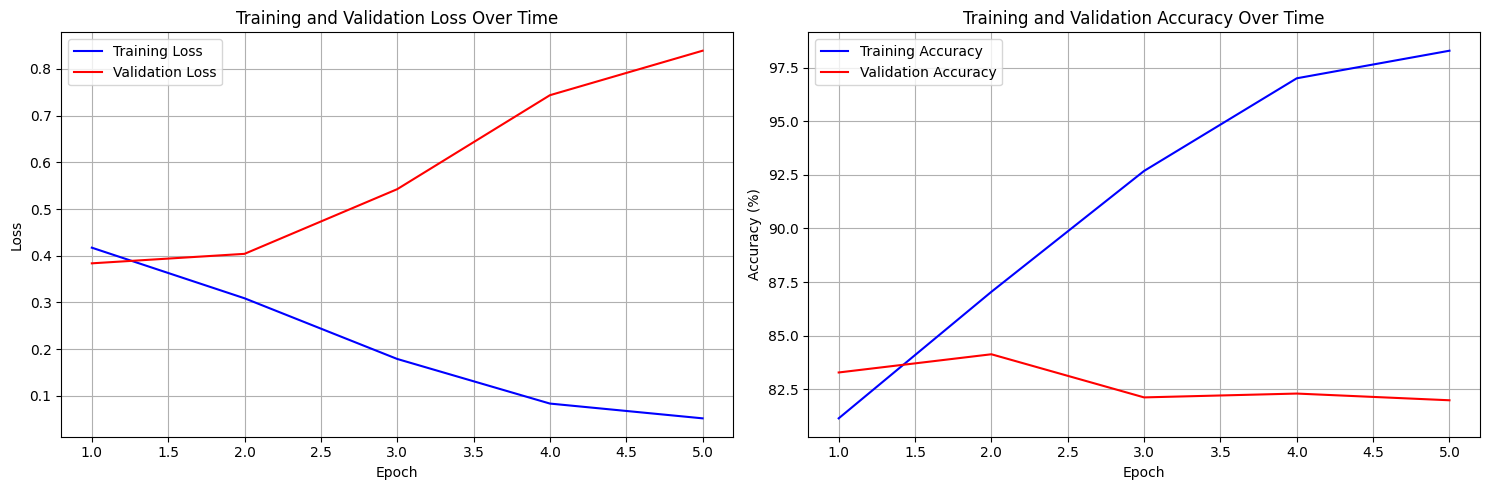


Final Results:
Best Validation Accuracy: 84.13%

Training History:
Epoch 1:
  Training   - Loss: 0.4173, Accuracy: 81.14%
  Validation - Loss: 0.3838, Accuracy: 83.28%
Epoch 2:
  Training   - Loss: 0.3090, Accuracy: 87.04%
  Validation - Loss: 0.4041, Accuracy: 84.13%
Epoch 3:
  Training   - Loss: 0.1791, Accuracy: 92.68%
  Validation - Loss: 0.5425, Accuracy: 82.12%
Epoch 4:
  Training   - Loss: 0.0836, Accuracy: 97.00%
  Validation - Loss: 0.7436, Accuracy: 82.30%
Epoch 5:
  Training   - Loss: 0.0520, Accuracy: 98.29%
  Validation - Loss: 0.8388, Accuracy: 81.98%


In [113]:
# Plotting training and validation metrics
import matplotlib.pyplot as plt

# Create a figure with two subplots
plt.figure(figsize=(15, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, 'b-', label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_losses, 'r-', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accs, 'b-', label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), val_accs, 'r-', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy Over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print final metrics
print("\nFinal Results:")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print("\nTraining History:")
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}:")
    print(
        f"  Training   - Loss: {train_losses[epoch]:.4f}, Accuracy: {train_accs[epoch]:.2f}%")
    print(
        f"  Validation - Loss: {val_losses[epoch]:.4f}, Accuracy: {val_accs[epoch]:.2f}%")

In [114]:
# Load best model
model.load_state_dict(torch.load(
    
    '/kaggle/working/informative_Attention_graph_V2.pth'))

# Evaluate on test set
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'\nTest Loss: {test_loss:.4f} Acc: {test_acc:.2f}%')

Evaluating:   1%|          | 1/140 [00:00<01:04,  2.14it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating: 100%|██████████| 140/140 [01:03<00:00,  2.20it/s]


Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.63      0.70       625
           1       0.87      0.94      0.90      1612

    accuracy                           0.85      2237
   macro avg       0.83      0.78      0.80      2237
weighted avg       0.85      0.85      0.85      2237


Test Loss: 0.3841 Acc: 85.16%


Getting test set predictions...


Getting predictions:   1%|          | 1/140 [00:00<00:43,  3.16it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Getting predictions: 100%|██████████| 140/140 [00:43<00:00,  3.23it/s]


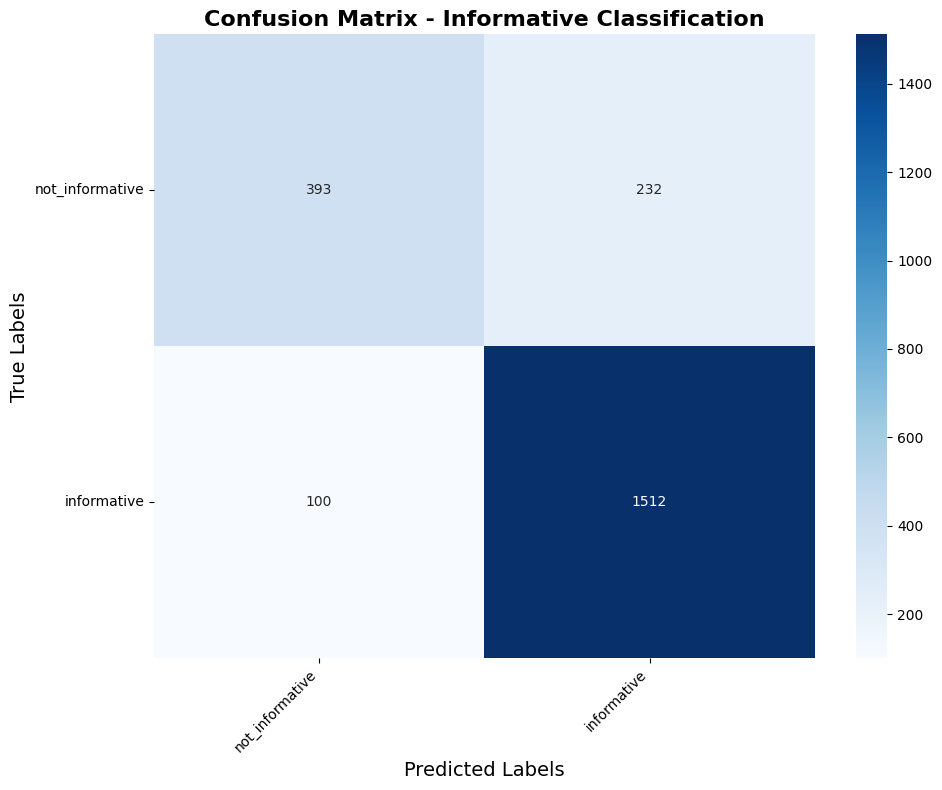

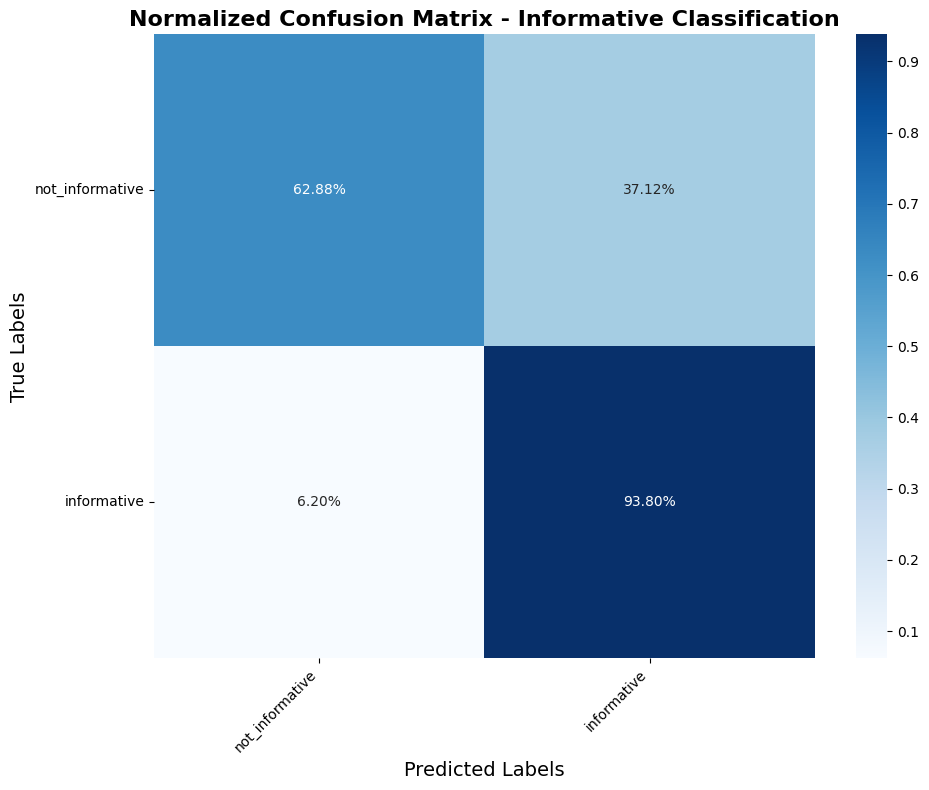


DETAILED CLASSIFICATION REPORT
                 precision    recall  f1-score   support

not_informative     0.7972    0.6288    0.7030       625
    informative     0.8670    0.9380    0.9011      1612

       accuracy                         0.8516      2237
      macro avg     0.8321    0.7834    0.8021      2237
   weighted avg     0.8475    0.8516    0.8457      2237


PER-CLASS ACCURACY ANALYSIS
not_informative          : 0.6288 (393/625 samples)
informative              : 0.9380 (1512/1612 samples)


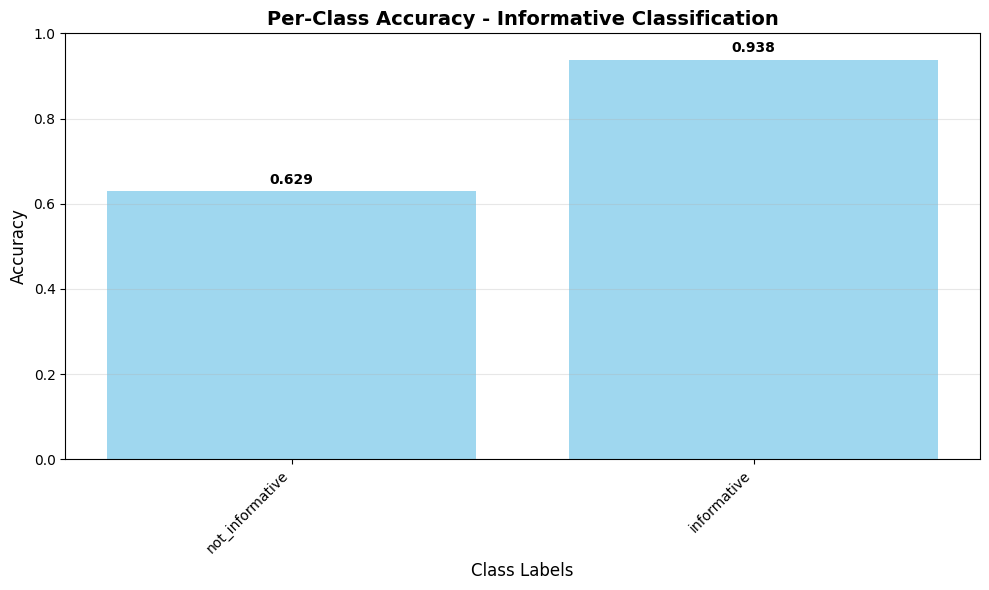


SUMMARY STATISTICS
Overall Test Accuracy: 0.8516
Best Performing Class: informative (0.9380)
Worst Performing Class: not_informative (0.6288)
Average Per-Class Accuracy: 0.7834
Standard Deviation: 0.1546

CLASS DISTRIBUTION IN TEST SET
not_informative          :  625 samples (27.9%)
informative              : 1612 samples (72.1%)

BINARY CLASSIFICATION METRICS
True Negatives:  393
False Positives: 232
False Negatives: 100
True Positives:  1512

Precision (Informative): 0.8670
Recall (Informative):    0.9380
Specificity:             0.6288
F1-Score:                0.9011


In [115]:
# Confusion Matrix and Detailed Analysis
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Function to get predictions for confusion matrix
def get_predictions(model, data_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc='Getting predictions'):
            images = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(images, input_ids, attention_mask)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return all_labels, all_preds

# Get predictions for test set
print("Getting test set predictions...")
test_labels, test_preds = get_predictions(model, test_loader, device)

# Create label mapping for better visualization
label_map = {'not_informative': 0, 'informative': 1}
reverse_label_map = {v: k for k, v in label_map.items()}
class_names = [reverse_label_map[i] for i in range(len(label_map))]

# Create confusion matrix
cm = confusion_matrix(test_labels, test_preds)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Informative Classification', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Normalized confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix - Informative Classification', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Detailed classification report
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT")
print("="*80)
print(classification_report(test_labels, test_preds, target_names=class_names, digits=4))

# Per-class accuracy analysis
print("\n" + "="*80)
print("PER-CLASS ACCURACY ANALYSIS")
print("="*80)
class_accuracies = cm.diagonal() / cm.sum(axis=1)
for i, (class_name, accuracy) in enumerate(zip(class_names, class_accuracies)):
    total_samples = cm.sum(axis=1)[i]
    correct_samples = cm.diagonal()[i]
    print(f"{class_name:25}: {accuracy:.4f} ({correct_samples}/{total_samples} samples)")

# Plot per-class accuracy
plt.figure(figsize=(10, 6))
plt.bar(range(len(class_names)), class_accuracies, color='skyblue', alpha=0.8)
plt.xlabel('Class Labels', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Per-Class Accuracy - Informative Classification', fontsize=14, fontweight='bold')
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

# Add accuracy values on top of bars
for i, accuracy in enumerate(class_accuracies):
    plt.text(i, accuracy + 0.01, f'{accuracy:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
overall_accuracy = np.trace(cm) / np.sum(cm)
print(f"Overall Test Accuracy: {overall_accuracy:.4f}")
print(f"Best Performing Class: {class_names[np.argmax(class_accuracies)]} ({class_accuracies.max():.4f})")
print(f"Worst Performing Class: {class_names[np.argmin(class_accuracies)]} ({class_accuracies.min():.4f})")
print(f"Average Per-Class Accuracy: {class_accuracies.mean():.4f}")
print(f"Standard Deviation: {class_accuracies.std():.4f}")

# Class distribution analysis
print("\n" + "="*80)
print("CLASS DISTRIBUTION IN TEST SET")
print("="*80)
unique_test, counts_test = np.unique(test_labels, return_counts=True)
for label_idx, count in zip(unique_test, counts_test):
    class_name = reverse_label_map[label_idx]
    percentage = count / len(test_labels) * 100
    print(f"{class_name:25}: {count:4d} samples ({percentage:.1f}%)")

# Additional metrics for binary classification
print("\n" + "="*80)
print("BINARY CLASSIFICATION METRICS")
print("="*80)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")
print(f"")
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f"Precision (Informative): {precision:.4f}")
print(f"Recall (Informative):    {recall:.4f}")
print(f"Specificity:             {specificity:.4f}")
print(f"F1-Score:                {f1_score:.4f}")

  warnings.warn(
                                                                    


1) Main Performance Table


,Accuracy,Precision_macro,Recall_macro,F1_macro
Full Model,0.8516,0.8321,0.7834,0.8021


  warnings.warn(
  warnings.warn(
  warnings.warn(
                                                                          


2) Ablation Table


...


5) Efficiency Table


,Total_params,Trainable_params,Approx_model_size_MB,Latency_ms_per_sample,Throughput_samples_per_sec
0,136534850,136534850,520.8391,20.3995,49.0207


  warnings.warn(
  warnings.warn(
  warnings.warn(
  warnings.warn(
                                                                    


6) Robustness Table


,Noise_std,Accuracy,F1_macro
0,0.00,0.8516,0.8021
1,0.01,0.8520,0.8025
2,0.03,0.8525,0.8037
3,0.05,0.8516,0.8032


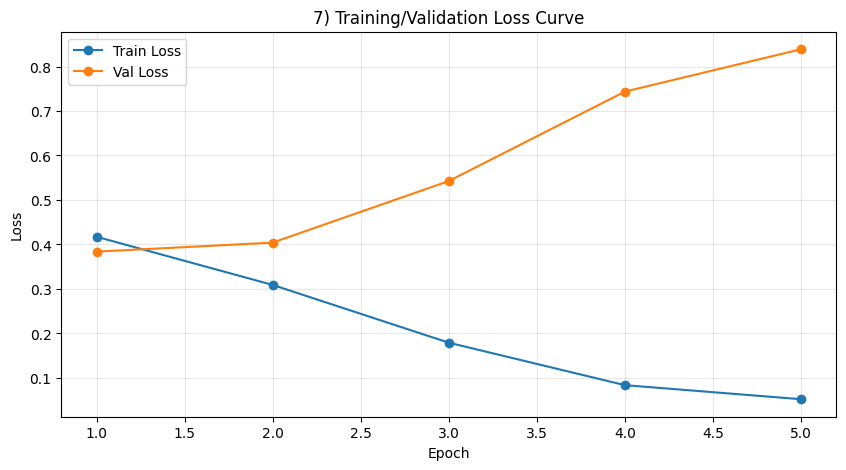

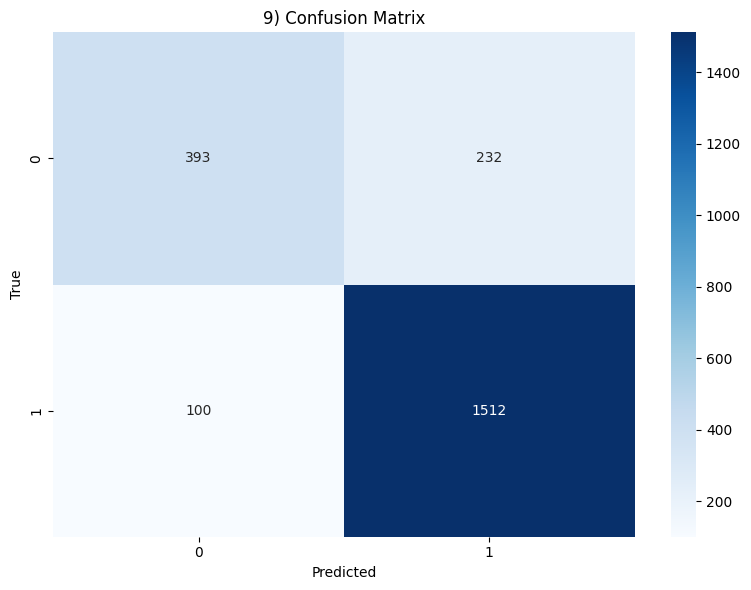

/tmp/ipykernel_177/2684354134.py:194: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Modality', y='Importance (Acc drop from full)', palette='viridis')


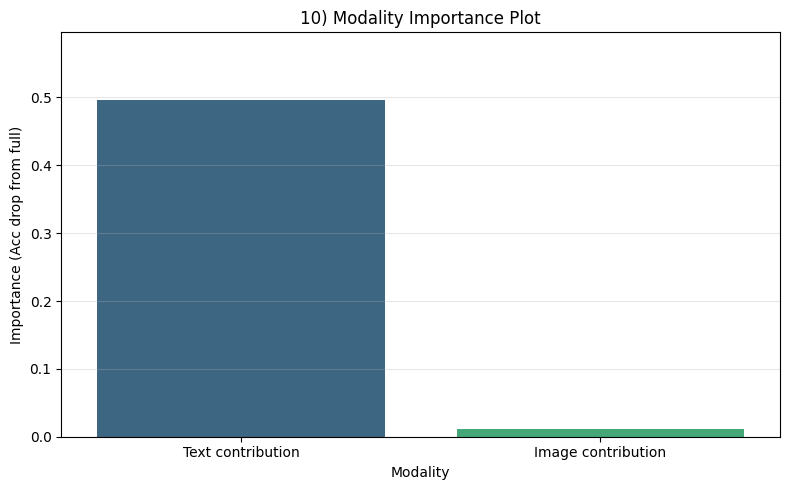

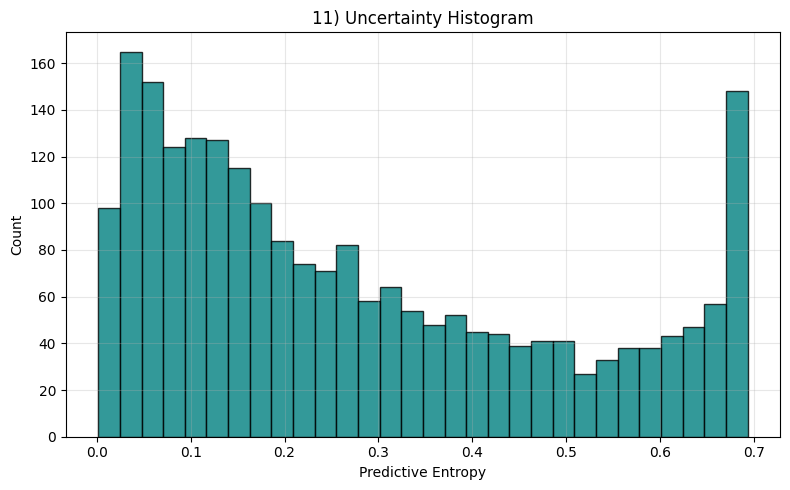

/tmp/ipykernel_177/2684354134.py:214: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conf_acc = c_df.groupby('bin').agg(


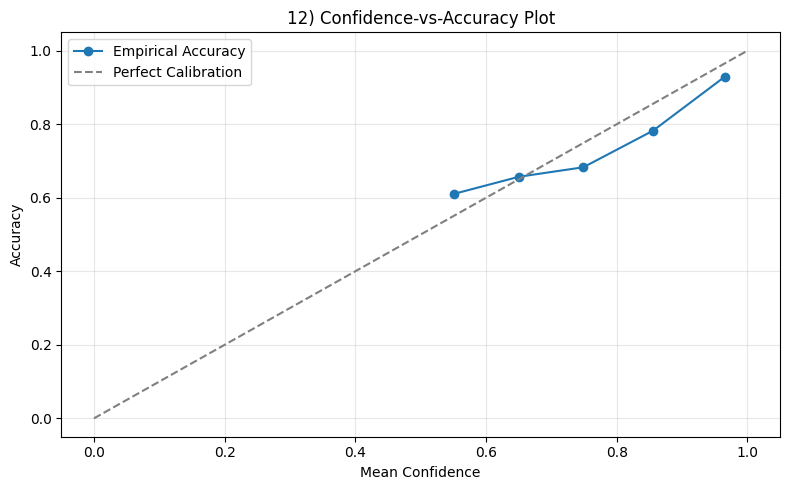

13) Attention Heatmap could not be generated: BertTokenizer has no attribute encode_plus

Results section completed.


In [116]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, f1_score
    )


def _forward_with_mode(model, images, input_ids, attention_mask, mode='full'):
    if mode == 'text_only':
        images = torch.zeros_like(images)
    elif mode == 'image_only':
        input_ids = torch.zeros_like(input_ids)
        attention_mask = torch.zeros_like(attention_mask)
    return model(images, input_ids, attention_mask)


@torch.no_grad()
def collect_predictions(model, loader, device, mode='full', max_batches=None, image_noise_std=0.0):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    for b_idx, batch in enumerate(tqdm(loader, desc=f'Collecting ({mode})', leave=False), 1):
        images = batch['image'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        if image_noise_std > 0:
            noise = torch.randn_like(images) * image_noise_std
            images = torch.clamp(images + noise, -3.0, 3.0)

        outputs = _forward_with_mode(model, images, input_ids, attention_mask, mode=mode)
        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

        if max_batches is not None and b_idx >= max_batches:
            break

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


def compute_summary_metrics(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision_macro': p,
        'Recall_macro': r,
        'F1_macro': f1
    }


def print_table(title, df):
    print(f"\n{'=' * 90}\n{title}\n{'=' * 90}")
    display(df)


# 1) Main performance table (Full model on test set)
y_true_full, y_pred_full, y_prob_full = collect_predictions(model, test_loader, device, mode='full')
main_metrics = compute_summary_metrics(y_true_full, y_pred_full)
main_perf_df = pd.DataFrame([main_metrics], index=['Full Model'])
print_table('1) Main Performance Table', main_perf_df.round(4))


# 2) Ablation table
ablation_rows = []
for mode_name, mode in [('Full', 'full'), ('Text only', 'text_only'), ('Image only', 'image_only')]:
    y_t, y_p, _ = collect_predictions(model, test_loader, device, mode=mode)
    m = compute_summary_metrics(y_t, y_p)
    m['Setting'] = mode_name
    ablation_rows.append(m)
ablation_df = pd.DataFrame(ablation_rows).set_index('Setting')
print_table('2) Ablation Table', ablation_df.round(4))


# 3) Per-class metrics table
per_class_report = classification_report(
    y_true_full, y_pred_full, output_dict=True, zero_division=0
    )
per_class_df = pd.DataFrame(per_class_report).T
per_class_df = per_class_df[~per_class_df.index.isin(['accuracy', 'macro avg', 'weighted avg'])]
print_table('3) Per-Class Metrics Table', per_class_df.round(4))


# 4) Uncertainty-performance table
eps = 1e-12
uncertainty = -np.sum(y_prob_full * np.log(y_prob_full + eps), axis=1)
confidence = np.max(y_prob_full, axis=1)
correct = (y_true_full == y_pred_full).astype(int)
u_df = pd.DataFrame({'uncertainty': uncertainty, 'correct': correct})
u_df['bin'] = pd.qcut(u_df['uncertainty'], q=5, duplicates='drop')
uncert_perf_df = u_df.groupby('bin').agg(
    Samples=('correct', 'count'),
    Accuracy=('correct', 'mean'),
    Uncertainty_mean=('uncertainty', 'mean')
).reset_index()
print_table('4) Uncertainty-Performance Table', uncert_perf_df.round(4))


# 5) Efficiency table (approximate benchmark on subset)
n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb = (n_params * 4) / (1024 ** 2)

bench_batches = 20
start = time.time()
_ = collect_predictions(model, test_loader, device, mode='full', max_batches=bench_batches)
elapsed = time.time() - start
samples_bench = min(len(test_dataset), bench_batches * test_loader.batch_size)
ms_per_sample = (elapsed * 1000.0) / max(samples_bench, 1)
throughput = samples_bench / max(elapsed, 1e-9)

efficiency_df = pd.DataFrame([{
    'Total_params': n_params,
    'Trainable_params': n_trainable,
    'Approx_model_size_MB': model_size_mb,
    'Latency_ms_per_sample': ms_per_sample,
    'Throughput_samples_per_sec': throughput
}])
print_table('5) Efficiency Table', efficiency_df.round(4))


# 6) Robustness table (image noise stress test)
robust_rows = []
for sigma in [0.00, 0.01, 0.03, 0.05]:
    y_t, y_p, _ = collect_predictions(
        model, test_loader, device, mode='full', image_noise_std=sigma
    )
    robust_rows.append({
        'Noise_std': sigma,
        'Accuracy': accuracy_score(y_t, y_p),
        'F1_macro': f1_score(y_t, y_p, average='macro')
    })
robustness_df = pd.DataFrame(robust_rows)
print_table('6) Robustness Table', robustness_df.round(4))


# 7) Training/validation loss curve
if 'train_losses' in globals() and 'val_losses' in globals() and len(train_losses) > 0:
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label='Train Loss')
    plt.plot(range(1, len(val_losses) + 1), val_losses, marker='o', label='Val Loss')
    plt.title('7) Training/Validation Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

# 8) Training/validation F1 curve
if 'train_f1s' in globals() and 'val_f1s' in globals() and len(train_f1s) > 0:
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(train_f1s) + 1), train_f1s, marker='o', label='Train F1 (macro)')
    plt.plot(range(1, len(val_f1s) + 1), val_f1s, marker='o', label='Val F1 (macro)')
    plt.title('8) Training/Validation F1 Curve')
    plt.xlabel('Epoch')
    plt.ylabel('F1-score')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

# 9) Confusion matrix
cm = confusion_matrix(y_true_full, y_pred_full)
class_names = sorted(list(set(y_true_full.tolist())))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('9) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# 10) Modality importance plots
full_acc = ablation_df.loc['Full', 'Accuracy']
text_only_acc = ablation_df.loc['Text only', 'Accuracy']
image_only_acc = ablation_df.loc['Image only', 'Accuracy']
importance_df = pd.DataFrame({
    'Modality': ['Text contribution', 'Image contribution'],
    'Importance (Acc drop from full)': [
        max(full_acc - image_only_acc, 0),
        max(full_acc - text_only_acc, 0)
    ]
})
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Modality', y='Importance (Acc drop from full)', palette='viridis')
plt.title('10) Modality Importance Plot')
plt.ylim(0, max(importance_df['Importance (Acc drop from full)'].max() * 1.2, 0.05))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 11) Uncertainty histogram
plt.figure(figsize=(8, 5))
plt.hist(uncertainty, bins=30, color='teal', alpha=0.8, edgecolor='black')
plt.title('11) Uncertainty Histogram')
plt.xlabel('Predictive Entropy')
plt.ylabel('Count')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 12) Confidence-vs-accuracy plot
c_df = pd.DataFrame({'confidence': confidence, 'correct': correct})
c_df['bin'] = pd.cut(c_df['confidence'], bins=np.linspace(0, 1, 11), include_lowest=True)
conf_acc = c_df.groupby('bin').agg(
    Accuracy=('correct', 'mean'),
    MeanConfidence=('confidence', 'mean'),
    Samples=('correct', 'count')
).reset_index()
plt.figure(figsize=(8, 5))
plt.plot(conf_acc['MeanConfidence'], conf_acc['Accuracy'], marker='o', label='Empirical Accuracy')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect Calibration')
plt.title('12) Confidence-vs-Accuracy Plot')
plt.xlabel('Mean Confidence')
plt.ylabel('Accuracy')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 13) Attention heatmap (BERT final layer CLS attention over tokens)
try:
    sample_text = str(test_df.iloc[0]['tweet_text'])
    enc = tokenizer.encode_plus(
        sample_text,
        add_special_tokens=True,
        max_length=64,
        truncation=True,
        padding='max_length',
        return_tensors='pt'
    )
    in_ids = enc['input_ids'].to(device)
    attn_mask = enc['attention_mask'].to(device)

    with torch.no_grad():
        attn_out = model.text_encoder(
            input_ids=in_ids, attention_mask=attn_mask, output_attentions=True
        )

    # transformers v2.x: attentions are usually last item in output tuple
    attentions = attn_out[-1] if isinstance(attn_out, (tuple, list)) else None
    if attentions is not None and len(attentions) > 0:
        last_layer = attentions[-1][0]  # [heads, seq, seq]
        cls_to_tokens = last_layer[:, 0, :].mean(dim=0).cpu().numpy()
        tokens = tokenizer.convert_ids_to_tokens(in_ids[0].cpu().numpy())

        valid_len = int(attn_mask[0].sum().item())
        cls_to_tokens = cls_to_tokens[:valid_len]
        tokens = tokens[:valid_len]

        plt.figure(figsize=(min(18, 0.35 * len(tokens) + 4), 3.5))
        sns.heatmap(
            cls_to_tokens.reshape(1, -1),
            cmap='magma',
            cbar=True,
            xticklabels=tokens,
            yticklabels=['CLS attention']
        )
        plt.title('13) Attention Heatmap (BERT CLS -> Tokens)')
        plt.xticks(rotation=60, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print('13) Attention Heatmap: attentions are not available from this model output.')
except Exception as e:
    print(f'13) Attention Heatmap could not be generated: {e}')

print('\nResults section completed.')